# Model 1: MobileNet Transformer
Designed by: Yuta Matsuzaki

### Iterations

| Version | Change | Test accuracy | Test macro F1 | Test weighted F1 | Decision |
|---|---|---:|---:|---:|---|
| V0 | Initial MobileNetV3 setup | 0.039 | 0.006 | 0.003 | Rejected: model collapsed and predicted almost all samples as one class |
| V1 | Fixed MobileNetV3 preprocessing by using `include_preprocessing=True` and removing manual `preprocess_input()` | 0.939 | 0.914 | 0.939 | ___ |
| V2 | V1 + expanded classifier head: added Dropout `GlobalAveragePooling2D → Dropout → Dense(NUM_CLASSES)` | 0.955 | 0.914 | 0.955 | ___ |
| V3 | V2 + removed class weights | ___ | ___ | ___ | ___ |
| V4 | Best setting + lower/higher learning rate | ___ | ___ | ___ | ___ |

In [1]:
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sys.path.append("..")
from shared_utils import (
    PROJECT_ROOT,
    load_data,
    eval_model,
    save_metrics,
    plot_training_history,
    get_class_weights,
)

2026-05-28 16:35:33.763811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779986133.778051  190487 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779986133.782244  190487 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779986133.794192  190487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779986133.794212  190487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779986133.794215  190487 computation_placer.cc:177] computation placer alr

In [2]:
# Configurations

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

# model directory
MODEL_DIR = PROJECT_ROOT / "transformer"

# Directory to save figures
FIGURES_DIR = MODEL_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Data Loading
data = load_data()

train_paths = data["train_paths"]
val_paths = data["val_paths"]
test_paths = data["test_paths"]

train_labels = data["train_labels"]
val_labels = data["val_labels"]
test_labels = data["test_labels"]

class_list = data["class_list"]
NUM_CLASSES = len(class_list)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))
print("Classes:", class_list)

print()
print("Example train image:")
print(train_paths[0])
print("Exists:", Path(train_paths[0]).exists())

Train: 10859
Val: 2328
Test: 2328
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

Example train image:
/home/n11902736/cab420/WasteClassification/data/garbage_classification/clothes/clothes3810.jpg
Exists: True


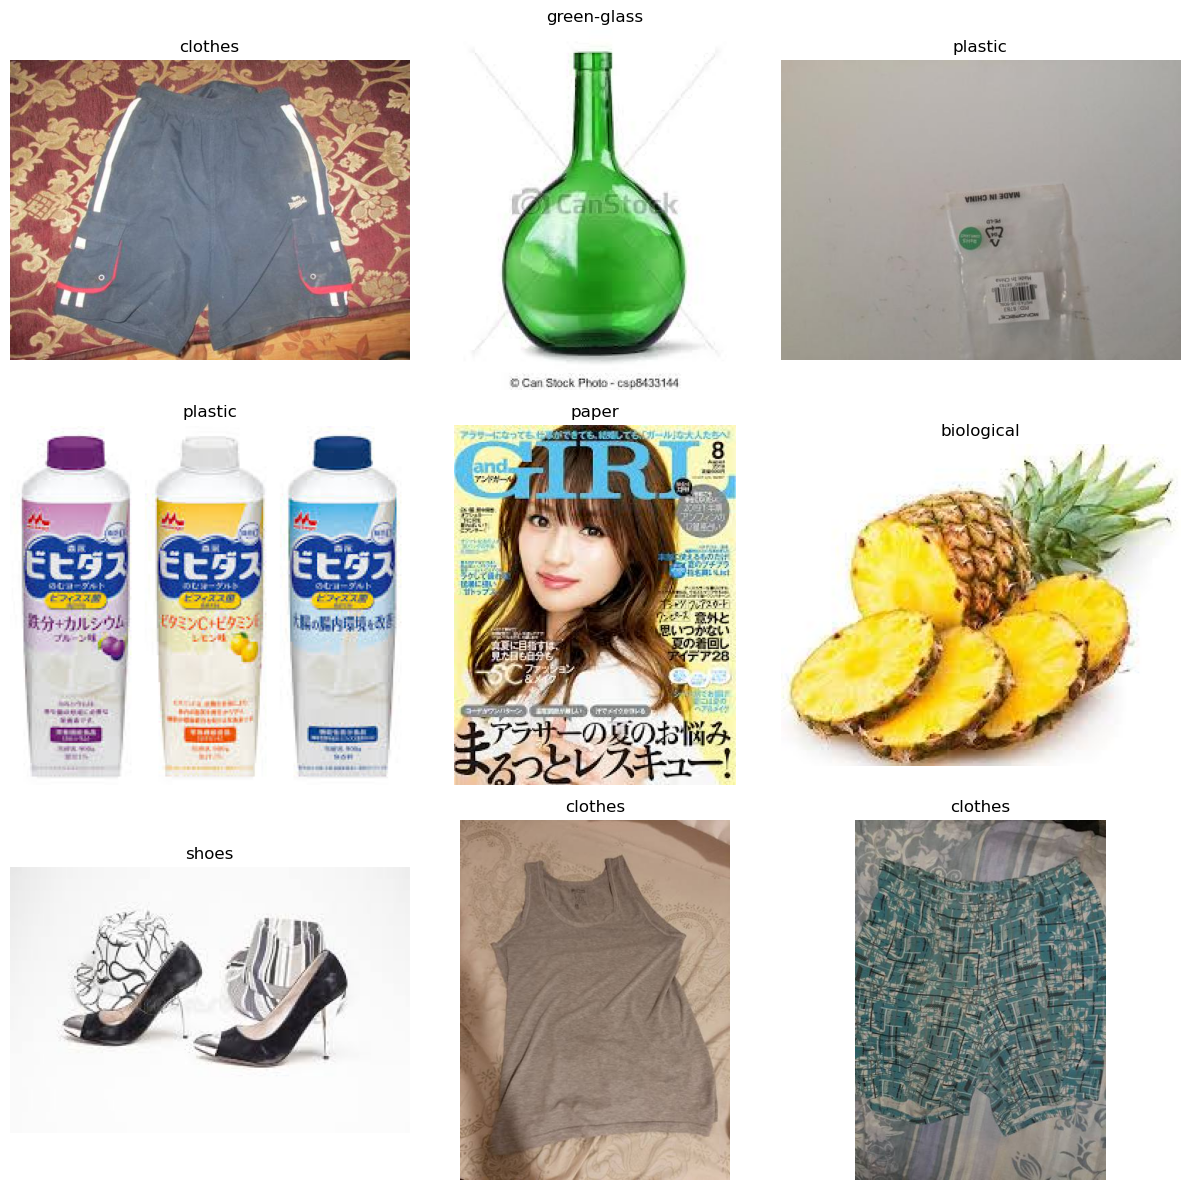

Saved: /home/n11902736/cab420/WasteClassification/transformer/figures/sample_training_images.png


In [4]:
# Plot random samples
def plot_random_samples(paths, labels, class_list, n=9):
    sample_indices = np.random.default_rng(RANDOM_STATE).choice(
        len(paths),
        size=n,
        replace=False,
    )

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    for ax, idx in zip(axes, sample_indices):
        img = Image.open(paths[idx]).convert("RGB")

        ax.imshow(img)
        ax.set_title(class_list[int(labels[idx])])
        ax.axis("off")

    plt.tight_layout()

    figure_path = FIGURES_DIR / "sample_training_images.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")

    plt.show()
    print("Saved:", figure_path)

plot_random_samples(train_paths, train_labels, class_list)

## Class Weights

In [5]:
# Allocate the weights for each class (Minority classes get higher weights)
class_weights = get_class_weights(train_labels)

print("Class weights:")
for label, weight in class_weights.items():
    print(f"{label:>2d} {class_list[label]:>15s}: {weight:.3f}")

Class weights:
 0         battery: 1.369
 1      biological: 1.313
 2     brown-glass: 2.129
 3       cardboard: 1.453
 4         clothes: 0.243
 5     green-glass: 2.052
 6           metal: 1.679
 7           paper: 1.231
 8         plastic: 1.496
 9           shoes: 0.654
10           trash: 1.854
11     white-glass: 1.667


## Build Tensorflow Dataset


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

LEARNING_RATE = 3e-4
EPOCHS = 50

In [7]:
def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False,
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

In [8]:
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(
    buffer_size=2000,
    seed=RANDOM_STATE,
    reshuffle_each_iteration=False,
)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Non-shuffled training dataset for train-set evaluation later.
train_eval_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_eval_ds = train_eval_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_eval_ds = train_eval_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

I0000 00:00:1779986137.084441  190487 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:04:0b.0, compute capability: 8.6


(32, 224, 224, 3)
(32,)


## Augmentation

In [9]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=RANDOM_STATE),
        layers.RandomRotation(0.08, seed=RANDOM_STATE),
        layers.RandomZoom(0.10, seed=RANDOM_STATE),
        layers.RandomTranslation(0.05, 0.05, seed=RANDOM_STATE),
    ],
    name="data_augmentation",
)

## MobileNetV3

In [10]:
# Reproducibility: Clear old model state before creating a new model, reset seeds
keras.backend.clear_session()
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

# Load MobileNetV3 backbone.
# include_preprocessing=True keeps MobileNetV3's expected preprocessing inside the model.
mobile_base = tf.keras.applications.MobileNetV3Small(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    include_preprocessing=True,
    weights="imagenet",
)

# Freeze backbone for first-stage transfer learning.
mobile_base.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))

x = data_augmentation(inputs)
x = mobile_base(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3, seed=RANDOM_STATE)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
)(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="mobilenet_v3_transfer")

model.summary()

Model: "mobilenet_v3_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,524 (3.87 MB)

 Trainable params: 75,404 (294.55 KB)

 Non-trainable params: 939,120 (3.58 MB)

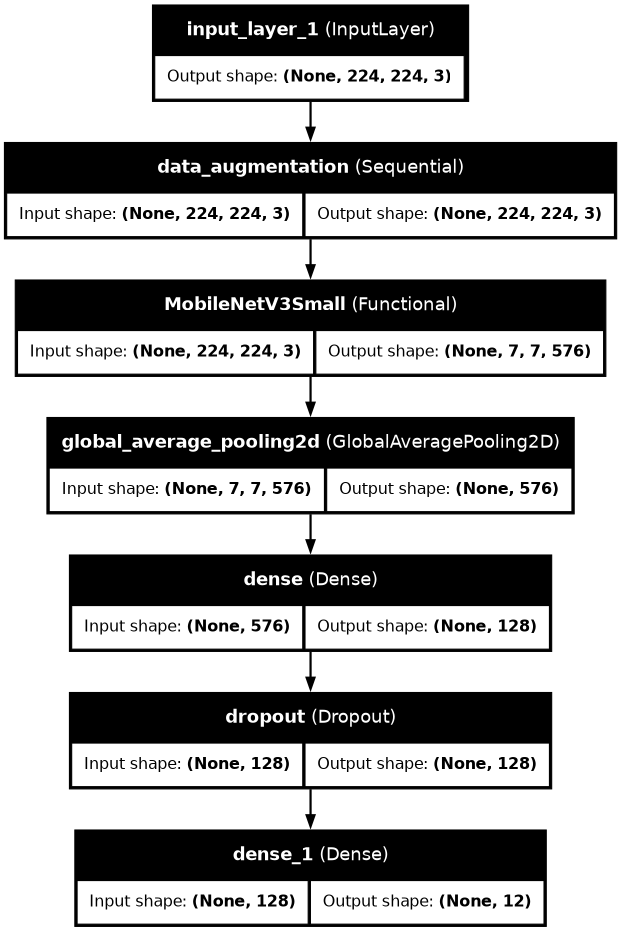

In [11]:
# Plot and save MobileNetV3 architecture
from IPython.display import Image, display

keras.utils.plot_model(
    model,
    to_file=FIGURES_DIR / "mobilenet_v3_model.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=80,
    expand_nested=False,
    rankdir="TB",
)

In [12]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [13]:
# Train model
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    )
]

start_time = time.perf_counter()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)

train_time = time.perf_counter() - start_time

print(f"Training time: {train_time:.2f}s")

Epoch 1/50


I0000 00:00:1779986143.893946  190528 cuda_dnn.cc:529] Loaded cuDNN version 90300


340/340 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.7186 - loss: 1.0839 - val_accuracy: 0.8960 - val_loss: 0.3626
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8487 - loss: 0.5617 - val_accuracy: 0.9188 - val_loss: 0.2784
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8791 - loss: 0.4490 - val_accuracy: 0.9253 - val_loss: 0.2432
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8903 - loss: 0.4009 - val_accuracy: 0.9300 - val_loss: 0.2257
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.9040 - loss: 0.3464 - val_accuracy: 0.9356 - val_loss: 0.2121
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.9103 - loss: 0.3253 - val_accuracy: 0.9377 - val_loss: 0.2058
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.9165 - loss: 0.2982 - val_accuracy: 0.9403 - val_loss: 0.1949
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.9207 - loss: 0.2791 - val_accurac

In [14]:
history_df = pd.DataFrame(history.history)

history_path = MODEL_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
display(history_df.head())

Saved: /home/n11902736/cab420/WasteClassification/transformer/training_history.csv


,accuracy,loss,val_accuracy,val_loss
0,0.718574,1.083851,0.896048,0.362627
1,0.848697,0.561672,0.918814,0.278370
2,0.879086,0.448978,0.925258,0.243188
3,0.890321,0.400928,0.929983,0.225674
4,0.904043,0.346406,0.935567,0.212061


Saved figure to: /home/n11902736/cab420/WasteClassification/transformer/figures/training_accuracy.png


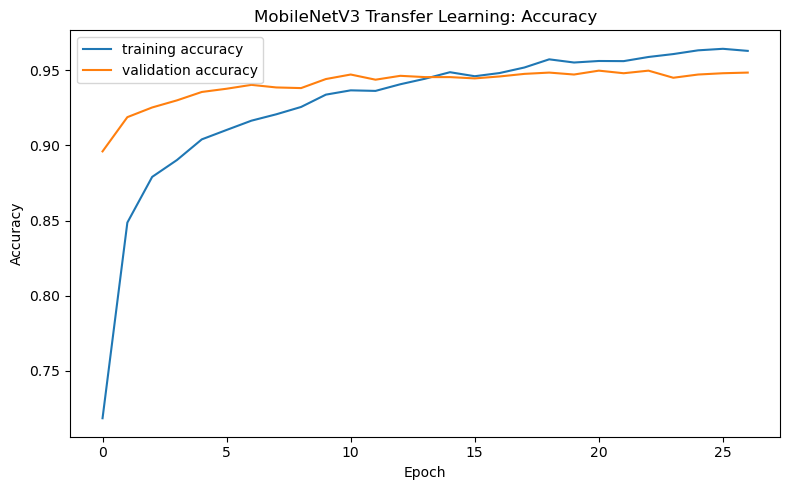

Saved figure to: /home/n11902736/cab420/WasteClassification/transformer/figures/training_loss.png


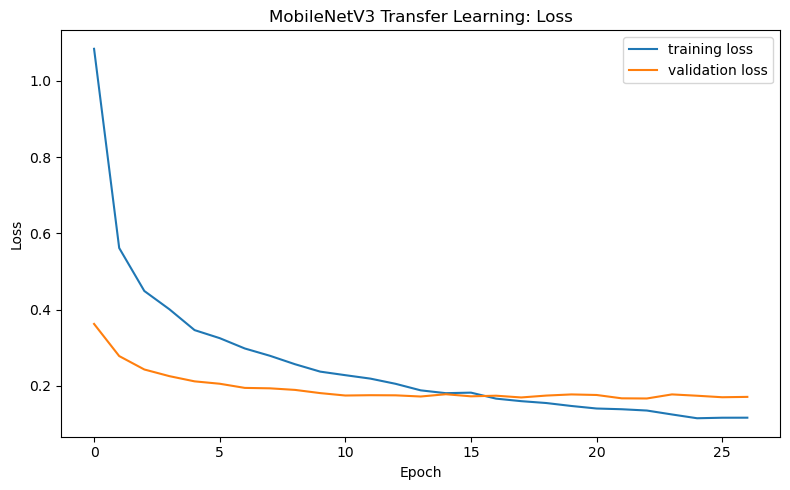

In [15]:
plot_training_history(
    history,
    title="MobileNetV3 Transfer Learning",
    save_dir=FIGURES_DIR,
)

340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
MobileNetV3 Transfer Learning
-----------------------------
Training time     : 404.34s
Inference time    : 13.020s
Time per sample   : 5.593ms
-----------------------------
              precision    recall  f1-score   support

     battery     0.9400    0.9930    0.9658       142
  biological     0.9732    0.9797    0.9764       148
 brown-glass     0.9663    0.9451    0.9556        91
   cardboard     0.9394    0.9254    0.9323       134
     clothes     0.9937    0.9850    0.9893       799
 green-glass     0.9890    0.9574    0.9730        94
       metal     0.8077    0.9130    0.8571       115
       paper     0.9231    0.9172    0.9201       157
     plastic     0.8672    0.8538    0.8605       130
       shoes     0.9633    0.9731    0.9682       297
       trash     0.9899    0.9333    0.9608       105
 white-glass     0.9196    0.8879    0.9035       116

    accuracy                         0.

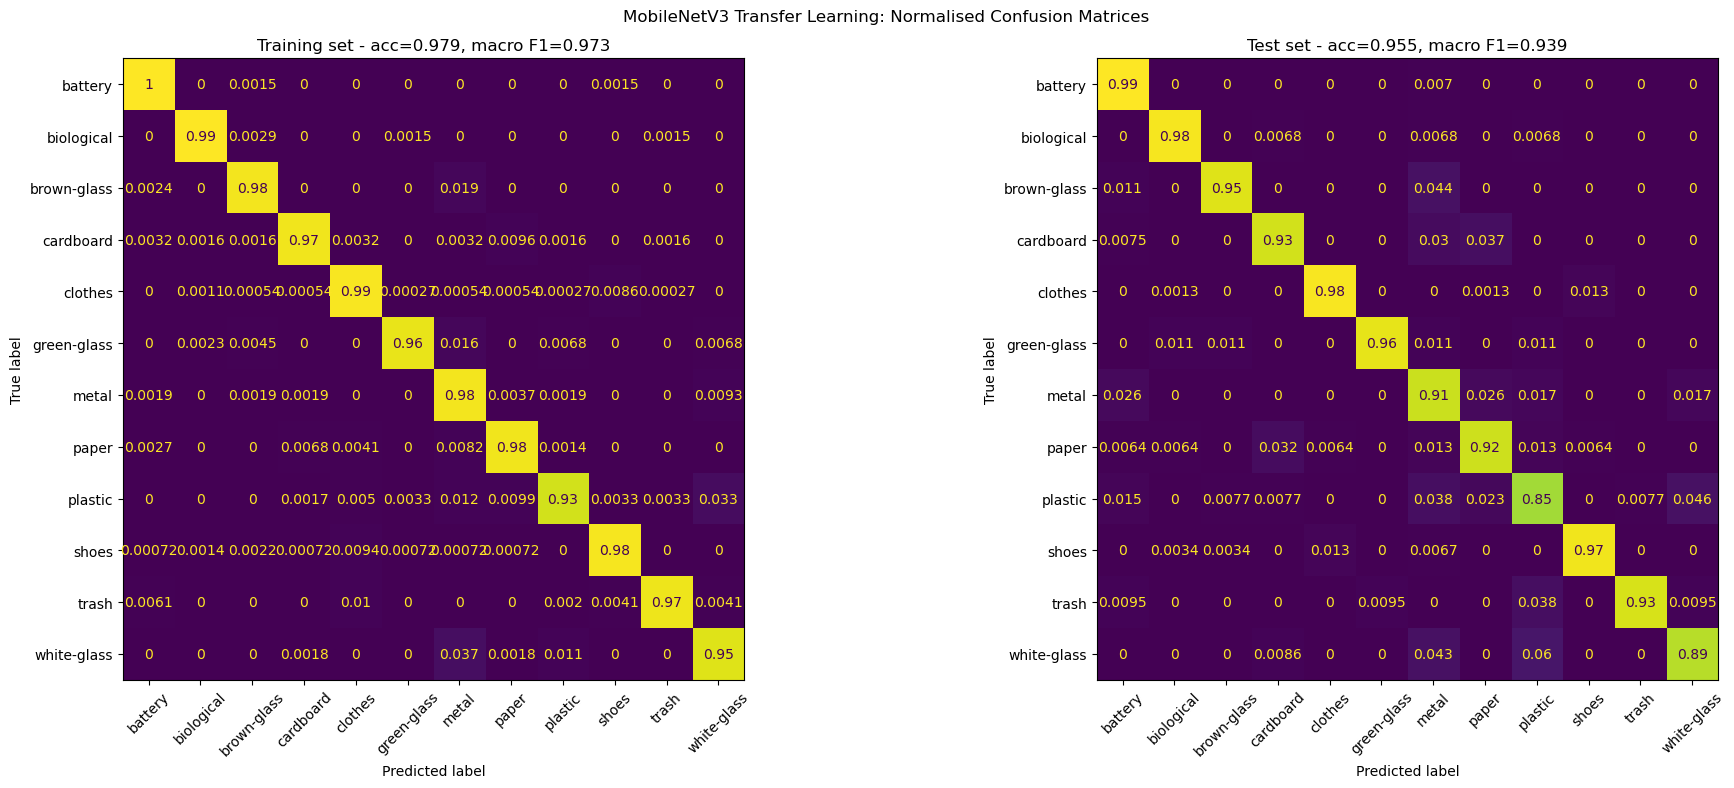

Saved metrics to: /home/n11902736/cab420/WasteClassification/transformer/mobilenet_v3_metrics.json


In [16]:
start_time = time.perf_counter()

train_prob = model.predict(train_eval_ds)
test_prob = model.predict(test_ds)

inference_time = time.perf_counter() - start_time

train_pred = np.argmax(train_prob, axis=1)
test_pred = np.argmax(test_prob, axis=1)

metrics = eval_model(
    test_labels,
    test_pred,
    class_list,
    model_name="MobileNetV3 Transfer Learning",
    y_train=train_labels,
    train_pred=train_pred,
    train_time=train_time,
    inference_time=inference_time,
    save_path=FIGURES_DIR / "mobilenet_v3_confusion_matrices.png",
)

save_metrics(
    metrics,
    MODEL_DIR / "mobilenet_v3_metrics.json",
)

## Save Predictions

In [17]:
predictions_df = pd.DataFrame({
    "path": test_paths,
    "true_label": test_labels,
    "true_class": [class_list[int(i)] for i in test_labels],
    "pred_label": test_pred,
    "pred_class": [class_list[int(i)] for i in test_pred],
    "confidence": np.max(test_prob, axis=1),
    "correct": test_labels == test_pred,
})

predictions_path = MODEL_DIR / "mobilenet_v3_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Saved:", predictions_path)
display(predictions_df.head())

Saved: /home/n11902736/cab420/WasteClassification/transformer/mobilenet_v3_predictions.csv


,path,true_label,true_class,pred_label,pred_class,confidence,correct
0,/home/n11902736/cab420/WasteClassification/dat...,0,battery,0,battery,0.999955,True
1,/home/n11902736/cab420/WasteClassification/dat...,0,battery,0,battery,0.999041,True
2,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,9,shoes,0.998794,True
3,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,4,clothes,0.999967,True
4,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,9,shoes,0.999301,True


## Analysis: High confidence misclassification

In [18]:
wrong_df = predictions_df[predictions_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values("confidence", ascending=False)

display(wrong_df.head(12))

,path,true_label,true_class,pred_label,pred_class,confidence,correct
922,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,9,shoes,0.999940,False
176,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,9,shoes,0.998729,False
2154,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,9,shoes,0.998021,False
1585,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,9,shoes,0.997506,False
807,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,9,shoes,0.995994,False
706,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,4,clothes,0.995659,False
1721,/home/n11902736/cab420/WasteClassification/dat...,8,plastic,11,white-glass,0.995105,False
759,/home/n11902736/cab420/WasteClassification/dat...,11,white-glass,6,metal,0.993928,False
2074,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,9,shoes,0.989713,False
1506,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,9,shoes,0.986571,False


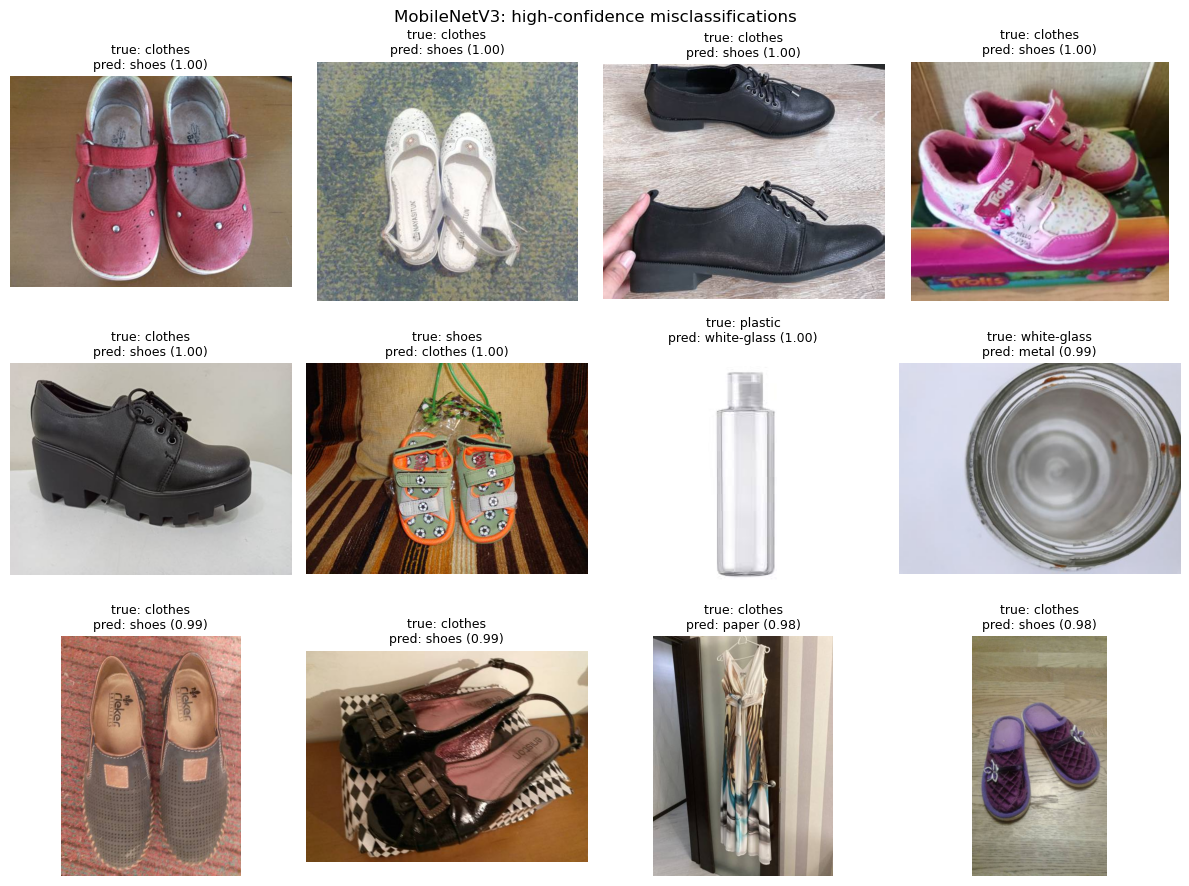

Saved: /home/n11902736/cab420/WasteClassification/transformer/figures/mobilenet_v3_high_confidence_errors.png


In [19]:
top_k = 12
failure_df = wrong_df.head(top_k)

n_cols = 4
n_rows = int(np.ceil(len(failure_df) / n_cols))

fig = plt.figure(figsize=(12, 3 * n_rows))

for plot_i, (_, row) in enumerate(failure_df.iterrows()):
    ax = fig.add_subplot(n_rows, n_cols, plot_i + 1)

    img = plt.imread(row["path"])
    ax.imshow(img)

    ax.set_title(
        f"true: {row['true_class']}\n"
        f"pred: {row['pred_class']} ({row['confidence']:.2f})",
        fontsize=9,
    )

    ax.axis("off")

fig.suptitle("MobileNetV3: high-confidence misclassifications", fontsize=12)
plt.tight_layout()

figure_path = FIGURES_DIR / "mobilenet_v3_high_confidence_errors.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)